# Applied TM 1: **Assignment 1**

### Group 4 (Manar Attar, Keze Hu, Carmen Popa, Rey Rashid)

#### **Link to the model trained**: https://drive.google.com/file/d/1nXReQV-to4MxnNzjwQHN7nMYSyjpXDQ9/view?usp=sharing

#### **References**

###### - Roser Morante and Eduardo Blanco. 2012. *SEM 2012 Shared Task: Resolving the Scope and Focus of Negation. In *SEM 2012: The First Joint Conference on Lexical and Computational Semantics – Volume 1: Proceedings of the main conference and the shared task, and Volume 2: Proceedings of the Sixth International Workshop on Semantic Evaluation (SemEval 2012)*, pages 265–274, Montréal, Canada. Association for Computational Linguistics. 
###### - Emanuele Lapponi, Erik Velldal, Lilja Øvrelid, and Jonathon Read. 2012. UiO 2: Sequence-labeling Negation Using Dependency Features. In *SEM 2012: The First Joint Conference on Lexical and Computational Semantics – Volume 1: Proceedings of the main conference and the shared task, and Volume 2: Proceedings of the Sixth International Workshop on Semantic Evaluation (SemEval 2012)*, pages 319–327, Montréal, Canada. Association for Computational Linguistics.
###### - Md. Faisal Mahbub Chowdhury. 2012. FBK: Exploiting Phrasal and Contextual Clues for Negation Scope Detection. In *SEM 2012: The First Joint Conference on Lexical and Computational Semantics – Volume 1: Proceedings of the main conference and the shared task, and Volume 2: Proceedings of the Sixth International Workshop on Semantic Evaluation (SemEval 2012)*, pages 340–346, Montréal, Canada. Association for Computational Linguistics.
###### - Amjad Abu-Jbara and Dragomir Radev. 2012. UMichigan: A Conditional Random Field Model for Resolving the Scope of Negation. In *SEM 2012: The First Joint Conference on Lexical and Computational Semantics – Volume 1: Proceedings of the main conference and the shared task, and Volume 2: Proceedings of the Sixth International Workshop on Semantic Evaluation (SemEval 2012)*, pages 328–334, Montréal, Canada. Association for Computational Linguistics.
###### - Daniel Jurafsky and James H. Martin. 2026. *Speech and Language Processing: An Introduction to Natural Language Processing, Computational Linguistics, and Speech Recognition with Language Models, 3rd edition*. Online manuscript released January 6, 2026. https://web.stanford.edu/~jurafsky/slp3.

### **Notebook Setup**

In [1]:
# Uncomment for installation. 
#!pip install -r requirements.txt

In [2]:
#Importing Python scripts with helper functions 
import util
from train import extract_features, extract_labels, train
import feature_extraction as fe

#Other modules
from collections import Counter
import spacy
from spacy.tokens import Doc
import benepar
from nltk.tree import Tree
import joblib
from spacy import displacy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
# !python -m spacy download en_core_web_md
# benepar.download('benepar_en3')

### **0 Loading Datasets and Combining Test Files**

In [3]:
#paths to the training and dev datasets
data_folder = '../data/cd-sco/corpus'
training_file = data_folder + '/training/SEM-2012-SharedTask-CD-SCO-training-09032012.txt'
dev_file = data_folder + '/dev/SEM-2012-SharedTask-CD-SCO-dev-09032012.txt'

In [4]:
## combining the test files without gold
test_file1_no_gold = data_folder + '/test/SEM-2012-SharedTask-CD-SCO-test-cardboard.txt'
test_file2_no_gold = data_folder + '/test/SEM-2012-SharedTask-CD-SCO-test-circle.txt'
test_file_no_gold_com= data_folder + '/test/test_combined.txt' #final test set file without gold
with open (test_file1_no_gold, 'r', encoding= 'utf-8') as t1:
    t1_content= t1.read()
with open (test_file2_no_gold, 'r', encoding= 'utf-8') as t2:
    t2_content= t2.read() 
t1_content += '\n' #adding an empty line to the end of doc 1 to separate
t1_content += t2_content #combining two doc contents
with open (test_file_no_gold_com, 'w', encoding= 'utf-8') as t3:
    t3.write(t1_content)
    
## combining the test files with gold, following the same steps above
test_file1_gold = data_folder + '/test-gold/SEM-2012-SharedTask-CD-SCO-test-cardboard-GOLD.txt'
test_file2_gold = data_folder + '/test-gold/SEM-2012-SharedTask-CD-SCO-test-circle-GOLD.txt'
test_file_gold_com= data_folder + '/test-gold/test_combined_with_gold.txt' #final test set file without gold
with open (test_file1_gold, 'r', encoding= 'utf-8') as t1g:
    t1g_content= t1g.read()
with open (test_file2_gold, 'r', encoding= 'utf-8') as t2g:
    t2g_content= t2g.read() 
t1g_content += '\n'
t1g_content += t2g_content
with open (test_file_gold_com, 'w', encoding= 'utf-8') as t3g:
    t3g.write(t1g_content)

### **1. Format Transformation and statistics**

#### 1.1 Training set

##### a) format transformation **training** set

In [5]:
#used the helper function in util.py
transformed_train= util.format_transformation (training_file, '../data/training.conll')

##### b) Statistics **Before** transformation

In [6]:
b4_train_sent, b4_train_token = util.extracting_sent_token_before_preprocessing(training_file)
print (f'The number of sentences in the training set before transformation: {len(b4_train_sent)}')
print (f'The number of tokens in the training set before transformation: {len(b4_train_token)}')

The number of sentences in the training set before transformation: 3644
The number of tokens in the training set before transformation: 65451


##### c) Statistics **after** transformation

In [7]:
af_train_sents, af_train_tokens, af_train_cues, af_train_tokens_in_scopes_count= util.extracting_info_after_preprocessing ('../data/training.conll')

#nr of sents and tokens
print (f'The number of sentences in the training set after transformation: {len(af_train_sents)}')
print (f'The number of tokens in the training set after transformation: {len(af_train_tokens)}') 

#nr of cues
print(f'The number of all cue instances in the training set after transformation: {len(af_train_cues)}')

#counting the number of tokens in all cues
train_cues_total_tokens = 0
for cue in af_train_cues:
    train_cues_total_tokens += len(cue.split())
print(f'The number of word tokens in all negation cues in the training data set after transformation: {train_cues_total_tokens}')

#finding the unique cue forms, as well as their distribution
lower_af_train_cues= []
for cue in af_train_cues:
    lower_af_train_cues.append(cue.lower()) #lowercasing the cues to count 'Not' and 'not' as the same, for instance
print(f'The number of unique cue forms in the training set after transformation: {len(set(lower_af_train_cues))}')
print(f'Cue Frequency distribution: {Counter(lower_af_train_cues)}')

#tokens in/outside scopes
print(f'The number of tokens in scope after training set transformation: {sum(af_train_tokens_in_scopes_count)}')
print(f'The number of tokens outside the scope after training set transformation: {len(af_train_tokens)-sum(af_train_tokens_in_scopes_count)}')

The number of sentences in the training set after transformation: 3780
The number of tokens in the training set after transformation: 69218
The number of all cue instances in the training set after transformation: 984
The number of word tokens in all negation cues in the training data set after transformation: 1003
The number of unique cue forms in the training set after transformation: 30
Cue Frequency distribution: Counter({'not': 356, 'no': 226, 'un': 80, "n't": 65, 'never': 59, 'nothing': 55, 'less': 28, 'without': 24, 'in': 22, 'im': 18, 'none': 12, 'nor': 6, 'ir': 6, 'dis': 5, 'by no means': 3, 'on the contrary': 2, 'neither nor': 2, 'prevent': 2, 'nowhere': 2, 'save': 1, 'nobody': 1, 'rather than': 1, 'not for the world': 1, 'fail': 1, 'except': 1, 'nothing at all': 1, 'neglected': 1, 'refused': 1, 'not not': 1, 'absence': 1})
The number of tokens in scope after training set transformation: 6978
The number of tokens outside the scope after training set transformation: 62240


#### 1.2 Development set

##### a) format transformation development set

In [8]:
#used the helper function in util.py
transformed_development= util.format_transformation (dev_file, '../data/dev.conll')

##### b) Statistics **Before** transformation

In [9]:
b4_dev_sent, b4_dev_token = util.extracting_sent_token_before_preprocessing(dev_file)
print (f'The number of sentences in the development set before transformation: {len(b4_dev_sent)}')
print (f'The number of tokens in the development set before transformation: {len(b4_dev_token)}')

The number of sentences in the development set before transformation: 787
The number of tokens in the development set before transformation: 13567


##### c) Statistics **After** transformation

In [8]:
af_dev_sents, af_dev_tokens, af_dev_cues, af_dev_tokens_in_scopes_count= util.extracting_info_after_preprocessing ('../data/dev.conll')

#nr of sents and tokens
print (f'The number of sentences in the development set after transformation: {len(af_dev_sents)}')
print (f'The number of tokens in the development set after transformation: {len(af_dev_tokens)}') 

#nr of cues
print(f'The number of all cue instances in the development set after transformation: {len(af_dev_cues)}')

#counting the number of tokens in all cues
dev_cues_total_tokens = 0
for cue in af_dev_cues:
    dev_cues_total_tokens += len(cue.split())
print(f'The number of word tokens in all negation cues in the development data set after transformation: {dev_cues_total_tokens}')

#finding the unique cue forms, as well as their distribution
lower_af_dev_cues= []
for cue in af_dev_cues:
    lower_af_dev_cues.append(cue.lower()) #lowercasing the cues to count 'Not' and 'not' as the same, for instance

print(f'The number of unique cue forms in the development set after transformation: {len(set(lower_af_dev_cues))}')
print(f'Cue Frequency distribution: {Counter(lower_af_dev_cues)}')

#tokens in scopes
print(f'The number of tokens in scope after dev set transformation: {sum(af_dev_tokens_in_scopes_count)}')
print(f'The number of tokens outside the scope after dev set transformation: {len(af_dev_tokens)-sum(af_dev_tokens_in_scopes_count)}')

The number of sentences in the development set after transformation: 816
The number of tokens in the development set after transformation: 14272
The number of all cue instances in the development set after transformation: 173
The number of word tokens in all negation cues in the development data set after transformation: 179
The number of unique cue forms in the development set after transformation: 20
Cue Frequency distribution: Counter({'not': 42, 'no': 32, "n't": 20, 'un': 16, 'nothing': 16, 'never': 11, 'without': 7, 'im': 6, 'in': 5, 'nor': 4, 'less': 3, 'neither nor': 2, 'dis': 2, 'no nor': 1, 'by no means': 1, 'neither': 1, 'ir': 1, 'save': 1, 'nobody': 1, 'no more': 1})
The number of tokens in scope after dev set transformation: 1368
The number of tokens outside the scope after dev set transformation: 12904


#### 1.3 Test set (with gold):  ***(USED FOR statistics and EVALUATION ONLY, NOT FOR MODEL TRAINING)***

##### a) format transformation test set

In [11]:
#used the helper function in util.py
transformed_development= util.format_transformation (test_file_gold_com, '../data/test_with_gold.conll')

##### b) Statistics **Before** transformation

In [12]:
b4_test_sent, b4_test_token = util.extracting_sent_token_before_preprocessing(test_file_gold_com)
print (f'The number of sentences in the test set before transformation: {len(b4_test_sent)}')
print (f'The number of tokens in the test set before transformation: {len(b4_test_token)}')

The number of sentences in the test set before transformation: 1089
The number of tokens in the test set before transformation: 19216


##### c) Statistics **After** transformation

In [9]:
af_test_sents, af_test_tokens, af_test_cues, af_test_tokens_in_scopes_count= util.extracting_info_after_preprocessing ('../data/test_with_gold.conll')

#nr of sents and tokens
print (f'The number of sentences in the combined test set after transformation: {len(af_test_sents)}')
print (f'The number of tokens in the combined test set after transformation: {len(af_test_tokens)}') 

#nr of cues
print(f'The number of all cue instances in the combined test set after transformation: {len(af_test_cues)}')

#counting the number of tokens in all cues
test_cues_total_tokens = 0
for cue in af_test_cues:
    test_cues_total_tokens += len(cue.split())
print(f'The number of word tokens in all negation cues in the combined test data set after transformation: {test_cues_total_tokens}')

#finding the unique cue forms, as well as their distribution
lower_af_test_cues= []
for cue in af_test_cues:
    lower_af_test_cues.append(cue.lower()) #lowercasing the cues to count 'Not' and 'not' as the same, for instance

print(f'The number of unique cue forms in the combined test set after transformation: {len(set(lower_af_test_cues))}')
print(f'Cue Frequency distribution: {Counter(lower_af_test_cues)}')


#tokens in scopes
print(f'The number of tokens in scope after combined test set transformation: {sum(af_test_tokens_in_scopes_count)}')
print(f'The number of tokens outside the scope after combined test set transformation: {len(af_test_tokens)-sum(af_test_tokens_in_scopes_count)}')

The number of sentences in the combined test set after transformation: 1118
The number of tokens in the combined test set after transformation: 19915
The number of all cue instances in the combined test set after transformation: 264
The number of word tokens in all negation cues in the combined test data set after transformation: 274
The number of unique cue forms in the combined test set after transformation: 20
Cue Frequency distribution: Counter({'not': 82, 'no': 50, "n't": 34, 'nothing': 22, 'never': 20, 'un': 19, 'without': 7, 'less': 5, 'in': 4, 'im': 3, 'neither nor': 3, 'dis': 3, 'nor': 3, 'ir': 2, 'no more': 2, 'far from': 1, 'neither nor nor': 1, 'none': 1, 'absolutely nothing': 1, 'never more': 1})
The number of tokens in scope after combined test set transformation: 1826
The number of tokens outside the scope after combined test set transformation: 18089


### **2. Features and Motivation (Individual)**

#### 2.0 Spacy Parsing part (shared)

In [11]:
nlp = spacy.load("en_core_web_md")
nlp.add_pipe("benepar", config={"model": "benepar_en3"})

In [10]:
###code adapted from the one from the Spacyparsing notebook, last accessed on 14 Jan, 2026
def parse_sent(sentence):
    """  
    Parse the sentence using Spacy and the added benepar.

    Parameters
    ----------
    sentence : list[str] or str

    Prints
    -------
    token plus parse information (token, lemma, pos, tag)
    """


    if type(sentence) == list:
        spacy_doc = Doc(nlp.vocab, words=sentence)
        processed_doc = nlp(spacy_doc)

    else:
        processed_doc = nlp(sentence)
    
    for sent in list(processed_doc.sents):    
        print([(token.text, token.lemma_, token.pos_, token.tag_) for token in sent]) 

        #If you want to see the tree and dependacy uncomment the following lines:
        
        # tree = sent._.parse_string
        # display(Tree.fromstring(tree))
        # displacy.render(sent, style="dep", options={"collapse_punct": False})
###

In [12]:
sent_list = util.conll_sentences_as_token_lists('../data/training.conll', token_col=3)

In [15]:
#testing the function written
for sent in sent_list[0:2]:
    print(sent)

['Chapter', '1.', 'Mr.', 'Sherlock', 'Holmes']
['Mr.', 'Sherlock', 'Holmes', ',', 'who', 'was', 'usually', 'very', 'late', 'in', 'the', 'mornings', ',', 'save', 'upon', 'those', 'not', 'infrequent', 'occasions', 'when', 'he', 'was', 'up', 'all', 'night', ',', 'was', 'seated', 'at', 'the', 'breakfast', 'table', '.']


In [16]:
#function testing
for sent in sent_list[0:2]:
    parse_sent(sent)
    print("\n")

[('Chapter', 'chapter', 'NOUN', 'NN'), ('1.', '1.', 'X', 'CD'), ('Mr.', 'Mr.', 'PROPN', 'NNP'), ('Sherlock', 'Sherlock', 'PROPN', 'NNP'), ('Holmes', 'Holmes', 'PROPN', 'NNP')]


[('Mr.', 'Mr.', 'PROPN', 'NNP'), ('Sherlock', 'Sherlock', 'PROPN', 'NNP'), ('Holmes', 'Holmes', 'PROPN', 'NNP'), (',', ',', 'PUNCT', ','), ('who', 'who', 'PRON', 'WP'), ('was', 'be', 'AUX', 'VBD'), ('usually', 'usually', 'ADV', 'RB'), ('very', 'very', 'ADV', 'RB'), ('late', 'late', 'ADV', 'JJ'), ('in', 'in', 'ADP', 'IN'), ('the', 'the', 'DET', 'DT'), ('mornings', 'morning', 'NOUN', 'NNS'), (',', ',', 'PUNCT', ','), ('save', 'save', 'VERB', 'JJ'), ('upon', 'upon', 'SCONJ', 'IN'), ('those', 'those', 'DET', 'DT'), ('not', 'not', 'PART', 'RB'), ('infrequent', 'infrequent', 'ADJ', 'JJ'), ('occasions', 'occasion', 'NOUN', 'NNS'), ('when', 'when', 'SCONJ', 'WRB'), ('he', 'he', 'PRON', 'PRP'), ('was', 'be', 'AUX', 'VBD'), ('up', 'up', 'ADV', 'RB'), ('all', 'all', 'DET', 'DT'), ('night', 'night', 'NOUN', 'NN'), (',', ',

#### 2.1 **Carmen**'s features

**Feature 1: Negation Cue Type**

The first feature is the type of the negation cue, inspired from the paper ‘UMichigan: A Conditional Random Field Model for Resolving the Scope of Negation’. This feature can help distinguish between different negation scope behaviors - single and multi-word negation cue types often hold a broader scope than the affix cues. In the single word negation cues, usually, the predicate + arguments/complements are included in the negation scope and are attached to a Verb Phrase (e.g. from training data, ’I am telling that which I have not confided to anyone’ - ‘not’ scopes over a Verbal Phrase) or a Noun Phrase (e.g. ’there are none of the family at the Hall’). These are syntactic cues. On the other hand, affixal cues, morphological negation cues (e.g. ‘un-‘, ‘im-‘, ‘-less’, etc.) are attached to the word, and usually introduce adjectives (JJ) (e.g. ‘It is unlikely that the composer of such a letter would be careless’), and the scope is more local.

This feature is represented as a string and will return the negation cue type for each sentence  as a list of strings (same negation cue type for each token of the sentence) with the following labels:
- SINGLE = a single word for the negation cue;
- PREFIX = when the token starts with negation morpheme;
- POSTFIX = when the token ends with negation morpheme;
- INFIX = when in rare cases the token has the negation morpheme internally;
- MULTI = when the negation cue is formed from more than one word;
- NO_CUE = when there are no negation cues;

The feature assumes there is only one negation cue per sentence, which is true since we duplicated the sentences with multiple negation cues in the dataset.

I chose to apply the same negation cue type label to each token in a particular sentence given the contextual and global nature of this feature. This works well for CRF models as CRF makes the decision based on local features at every token and keeping the same negation cue type for every token in a sentence provides the model information to expect a negation cue of specific type in the sentence. In this way, the model will be conditioned on whether a sentences contain a negation cue type and would work especially well with another feature like cue position. Also, it would help model with detecting different inside/outside scopes, to learn scope boundaries, and to reduce ambiguity in cases where the distance is not sufficient to detect the boundaries.	

As a note, I also included the infix negation cue as a type because while they rarely appear in the data, their scope is quite different than the others. For example, from the training data, ‘That may point to carelessness or it may point to agitation and hurry upon the part of the cutter.’/ ‘(…) and points especially to some affection of the heart, manifesting itself in changes of colour, breathlessness, and acute attacks of nervous depression’. In these exceptional cases, the scope is ‘care’ and ‘breath’, and the scope doesn’t cover other tokens because they are often limited to the token itself. This will help the model to distinguish these as separate cases with the help of this feature and not force them into categories in which they don’t belong because of the scope boundaries.

In [19]:
def negation_cue_type(sentence, neg_cues, non_cue_marker = '_'):
    """Feature that extracts the type of the negation cue:
        - NO_CUE
        - SINGLE : e.g. not
        - PREFIX : e.g. (un)important
        - POSTFIX : e.g. care(less)
        - INFIX : e.g. care(less)ness
        - MULTI : e.g. neither ... nor

    Assumes that the neg_cues only carries one negation cue in a sentence (single or multi word).

    args:
        sentence: List of string tokens, e.g. ['I', 'do', 'not', 'like', 'apples', '.']
        neg_cues: List which is negation cue token for negation cue and '_' otherwise. e.g. ['_', '_', 'not', '_', '_', '_']
        non_cue_marker: Marker in neg cue list for non-cue tokens, e.g. '_' by default.

    returns: type of the negation cue encoded as a string.
    """
    neg_cue_type = 'NO_CUE'
    sentence_length = len(sentence) 

    # Check if number of non negation cue markers are one less than total tokens, ie there is one negation cue.
    if neg_cues.count(non_cue_marker) == sentence_length - 1:
        neg_cue_index = -1

        # Find the index of negation cue in the sentence.
        for index, token in enumerate(neg_cues):
            if token != non_cue_marker:
                neg_cue_index = index

        neg_cue = neg_cues[neg_cue_index]
        neg_token = sentence[neg_cue_index]
        
        # Check if the token at the negation cue index in sentence is equal to negation cue.
        if neg_token == neg_cue:
            neg_cue_type = 'SINGLE'
        # Check if the token at the negation cue index in sentence starts with negation cue.
        elif neg_token.startswith(neg_cue):
            neg_cue_type = 'PREFIX'
        # Check if the token at the negation cue index in sentence ends with negation cue.
        elif neg_token.endswith(neg_cue):
            neg_cue_type = 'POSTFIX'
        # Check if the token at the negation cue index in sentence contains negation cue in the middle.
        elif neg_cue in neg_token:
            neg_cue_type = 'INFIX'
        # Check if the token at the negation cue index in sentence has no overlap with negation cue.
        # Possibly due to unclean or incorrect data.
        else:
            neg_cue_type = 'UNKNOWN'
    
    # If there are more than one negation cues, then is a multi-word negation cue type.
    elif neg_cues.count(non_cue_marker) < sentence_length - 1:
        neg_cue_type = 'MULTI'
        
    return [neg_cue_type] * sentence_length

**Feature 2: Is cue and token in different S or SBAR clause**

The second feature is ‘is cue and token in different S or SBAR’, inspired from the paper ‘FBK: Exploiting Phrasal and Contextual Clues for Negation Scope Detection’. The feature informs whether the closest S/SBAR clause to cue and token are different or the same. It is a constituency-based feature that can detect the boundaries of the negation scope. Usually, in many constructions, the negation cue negates the main predicate and its arguments/complements, and if tokens are in different clauses or subordinate clauses that don’t belong to the negation cue clause, then most probably the token is outside the scope. As a result, this feature helps the model with detecting the scope boundaries.

For example, from training data, ’Well, I couldn’t be sure of that, but I dare say my fare knew all about it.’, the S clause that belongs to the negation cue ’n’t’ includes ‘I could be sure of that’, then ‘but’ is a boundary, and from that point on until the end of the sentence the words belongs to a different S clause, which indicates that they are outside the scope. This feature strongly signals the boundary of the scope because in most cases the negation cue is bounded to the clause, and clauses and subordinate clauses (sometimes introduced by ‘but’, ‘however’, ‘that’ etc.) indicate the parts that usually correspond to different propositions. The intuition behind it says that most probably if the cue token and a token don’t belong to the same S/SBAR constituent, then the token in most cases is outside the negated meaning. This feature also works well with the CRF models because it can help model with learning hierarchical sentence structure.

In order to compute this feature, I walked over the spacy parse trees of the sentence tokens from the token and cue leafs, and found the closest S/SBAR nodes. During this feature development, I also found an interesting case where a sentence had two separate parse trees instead of one.

This feature will return a list of strings for each token in a sentence with following labels:
- NO_NEG_CUE = for words that are no negation cues;
- DIFF_S_SBAR = for words that are in different S/SBAR;
- SAME_S_SBAR = for words that are in the same S/SBAR.


In [20]:
def is_cue_and_token_in_diff_S_or_SBAR_clause(sentence, neg_cues, non_cue_marker = '_'):
    """Feature that indicates whether each token of the sentence belongs to different S/SBAR clause compared to negation cue,
        ie, whether the token and cue cross the clause boundary.

    Assumes that the neg_cues only carries one negation cue in a sentence (single or multi word).

    args:
        sentence: List of string tokens, e.g. ['I', 'do', 'not', 'like', 'apples', '.']
        neg_cues: List which is negation cue token for negation cue and '_' otherwise. e.g. ['_', '_', 'not', '_', '_', '_']
        non_cue_marker: Marker in neg cue list for non-cue tokens, e.g. '_' by default.

    returns: List of strings where for each token the value is 'DIFF_S_SBAR' if the token is in different S/SBAR than negation cue,
        else it is 'SAME_S_SBAR'. e.g. ['DIFF_S_SBAR', 'DIFF_S_SBAR', 'DIFF_S_SBAR', 'DIFF_S_SBAR', 'DIFF_S_SBAR', 'DIFF_S_SBAR'].
        If there is no negation cue, the value for a token is 'NO_NEG_CUE'.
    """
    feature = list()
    # Spacy constituency parsing (used from the class notebook).
    spacy_doc = Doc(nlp.vocab, words=sentence)
    processed_doc = nlp(spacy_doc)
    sentence_length = len(sentence)
    # display(Tree.fromstring(tree_str))

    neg_cue_index = -1
    
    # Find the index of negation cue in the sentence.
    for index, token in enumerate(neg_cues):
        if token != non_cue_marker:
            neg_cue_index = index

    # If there is no negation cue, then for each token in sentence, the category is 'NO_NEG_CUE'.
    if neg_cue_index == -1:
        return ['NO_NEG_CUE'] * sentence_length

    token_clause_ids = list()
    # Process each separate tree in the parsed sentence.
    # Some sentences may have more than one tree (e.g. "What! you don't mean to say" has two trees)
    for processed_sentence in list(processed_doc.sents):
        tree_str = processed_sentence._.parse_string
        tree = Tree.fromstring(tree_str)
        # Find the leaf position of each token in the tree and parse the tree upwards to find the closest S/SBAR node.
        for index in range(len(processed_sentence)):
            leaf = tree.leaf_treeposition(index)
            found = None
            # Parse the tree upwards
            for i in range(len(leaf), 0, -1):
                parent = leaf[:i-1]
                node = tree[parent]
                if node.label() in {"S", "SBAR"}:
                    found = parent
                    break
            # Append the id of the closest S/SBAR node of the token to corresponding token index.
            token_clause_ids.append(found)

    # For each token in the sentence, check if the S/SBAR node id is different for token and neg cue.
    for index in range(sentence_length):
        if token_clause_ids[index] != token_clause_ids[neg_cue_index]:
            feature.append('DIFF_S_SBAR')
        else:
            feature.append('SAME_S_SBAR')

    return feature

#### 2.2 **Keze**'s features

Feature 1: **Token and Relevant Position** <br /> 

The first feature is token-related, containing two sub-features: tokens by themselves and 
their position with respect to the negation cue. <br /> 
Tokens by themselves are extracted together as a group from the transformed files, which are represented as textual values before vectorisation (i.e. ‘Mr.’). The importance of tokens is self-evident, as in essence, this task is framed at the token level. They provide the basis for linear dependency among features. Meanwhile, tokens provide the surface lexical evidence. For instance, in observing the token frequency, the model can learn certain terms are consistently not in the scope. <br /> 

The second token-based feature concerns the relative position between the target token and the negation cue token, inspired by Abu-Jbara and Radev (2012). This feature is extracted with the help of a list of tokens (str) and cue labels (str), which point to the indices of the tokens and cue tokens. This feature is represented as numeric values:
- **0**= no negation cue, 
- **1**= before the negation cue; 
- **2**= is/ part of the cue token(s); 
- **3**= after the cue token
  
This feature is useful since in many languages there is a pattern concerning negation. For example, in English, the sentence components affected by the negation cue are always to the right (i.e., ‘after’ (3)) of the cue token. For instance, in ‘He did not like apples’, ‘like apples’ is highly likely to be in the scope. As a result, the model might observe these similar patterns. Meanwhile, given the annotation guideline, if the token is part of/the cue itself, it is out of the scope. Therefore, with a value indicating is_cue (2), the model might learn to exclude this from the scope.

In [21]:
def cue_token_position (token, cue_labels):
    """
    extract the relevant position of a token w.r.t the negation cue token in the sentence, using the values below:
    0 == the sentence has *no negation cues*
    1 == the token is *before* the token
    2 == the token *is / part of* the negation cue token(s)
    3 == the token is *after* the negation token
    Parameters
    ----------
    token: a list of string
    cue_labels: a list of strings with binary cue-labels ('_'/'x')
        Path to the input file with the 10-column format conll file.
        
    Returns
    -------
    list
        A list of numericposition values mentioned above
    """
    
    position= []
          
    #finding the cue index (i.e. the position of the (first) cue token in a sent)    
    cue_index= -1 #setting index value to -1 at default, meaning that the sent has no neg cues
    for i, cue_label in enumerate(cue_labels):
        if cue_label != '_':
            #only captures the first occurrence of a cue, and overwrites the cue_index
            cue_index= i
            break 
                
    for i, (token, cue_label) in enumerate (zip(token,cue_labels)):
        #if a sent has no neg cues (index== -1), position value= 0)
        if cue_index == -1:
            position.append(0)
        #addressing cues with any number of words: as long as cue label is not _, the position value is always 2 (the cue itself)
        elif cue_label != '_':
            position.append (2)  
        #tokens after are assigned with 3    
        elif i< cue_index:
            position.append(1)
        #tokens after are assigned with 3
        elif i> cue_index:
            position.append(3)
    return position


Feature 2: **Phrasal LCA and boundary** <br /> 

The second feature conjugates a few constituency-informed features in the papers: ‘constituents’ (Lapponi et al. 2012), ‘chunk’, ‘same chunk’, and ‘common ancestor node’ (Abu-Jbara and Radev 2012). In other words, the feature aims to find the least common ancestor (i.e., the smallest constituent unit between the token and the negation cue (e.g., NP, VP and PP)), as well as the phrasal boundary. This feature is useful since, if an LCA is found, the token is likely in the scope. For instance, in ‘I had an unpleasant journey although I met a kind person’, the LCA between ‘unpleasant’ (‘un-’ being the cue) and ‘journey’ is NP, and ‘journey’ is thus highly likely in the scope. This LCA finding process excludes the root (the sentence itself) and higher-level sentential constituent relations (i.e., ‘S’/‘SBAR’) to ensure a more precise relationship. <br /> 

Furthermore, the token is classified regarding its position in the phrase (i.e., beginning, inside and end). This helps the model notice the boundary of the scope. For instance, ‘journey’ is the end of the NP, so the model can learn not to include the rest of the sentence in the scope. <br /> 

The above-discussed feature is extracted using the methods in the benepar_en3 constituency parser. Meanwhile, this feature is represented as categorical values with a set of labels:
- **O**= No negation cue in the sentence/ No LCA
- **B-XP**= The token is at the beginning of the LCA phrase (e.g., NP/VP/ADJP or XP if there is no parsing label)
- **I-XP**= The token is inside the LCA phrase
- **E-XP**= The token marks the end of the LCA phrase


In [22]:
def cue_token_same_phrase_and_BIE (token, cue_labels):
    """
    extract the least common ancestor between a token and a cue at the phrasal level, as 
    well as the phrasal boundaries:
    O= No negation cue in the sentence/ No LCA
    B-XP= The token is at the beginning of the LCA phrase
    I-XP= The token is inside the LCA phrase
    E-XP= The token marks the end of the LCA phrase
    Parameters
    ----------
    token: a list of string
    cue_labels: a list of strings with binary cue-labels ('_'/'x')
    
        
    Returns
    -------
    list
        A list of categorical values mentioned above
    """    
    lca= []
    
    # preparing the Spacy doc by feeding in sent as a list of tokens
    ###fix suggested by Gemini regarding the error of NonConstituentException due to the strage quotation marks, last accessed on 15 Jan
    clean_tokens = [t.replace("``", '"').replace("''", '"') for t in token]
    ###
    doc = Doc(nlp.vocab, words=clean_tokens)
    pro_doc = nlp(doc)
    cue_indices= []
    #extracting cue indices
    for i, label in enumerate(cue_labels):
        if label != '_':
            cue_indices.append(i)
    
        #for sents without negation cues, a O is given.
    if not cue_indices:
        lca.extend(['O'] * len(token)) # Changed token_per_sent to token
    else:
    
        #defining the negation cue boundary
        cue_start = min(cue_indices)
        cue_end = max(cue_indices) + 1
        
        for i in range (len(token)):
            phrase = None
            lca_label = 'O'
            ###fix suggested by Gemini on  NonConstituentException, obtained on 15 Jan
            for s in pro_doc.sents:
            ###
                ### span methods inspired by the official Github of the parser (https://github.com/mrdrozdov/self-attentive-parser-with-extra-features),
                #last accessed: 15 Jan
                for constituent in s._.constituents:
                    if (constituent.start <= cue_start and constituent.end >= cue_end and constituent.start <= i < constituent.end):
                        if len(constituent)== len(doc): #skipping the root 
                            continue
                        if phrase is None or len(constituent) < len(phrase): #iterating over the smallest consti unit
                            phrase = constituent
                            lca_label = constituent._.labels[0] if constituent._.labels else "XP"
                ###
            if phrase: #Checks if the target token and the cue in the same phrase
                if lca_label =='S' or lca_label == 'SBAR': #the feature is phrase-oriented, so 'S' and 'SBAR' labels are converted to O
                    lca_bie= ('O')
                else:
                    #assigning Beginning/End/Inside depending on the position
                    if i == phrase.start:
                        lca_bie= (f'B-{lca_label}')
                    elif i == phrase.end-1:
                        lca_bie= (f'E-{lca_label}')
                    else:
                        lca_bie= (f'I-{lca_label}')
        
            else:
                lca_bie=('O')
                    
            lca.append(lca_bie)
    
        
    return lca

#### 2.3 **Manar**'s features

Feature 1: Motivation:The boundary token indicator is a boolean surface feature that marks tokens which represent strong boundaries in a sentence, such as punctuation marks (e.g., commas or periods) or discourse separators like but and however. These elements often correspond to clause breaks, and negation scope rarely continues beyond them. For example, in the sentence “I do not like the movie, but I enjoyed the soundtrack.”, the comma and the word but clearly separate two clauses. Although the word enjoyed appears relatively close to the negation cue not, it should not be included in the negation scope. A CRF model processes sentences sequentially and does not have an inherent notion of clause boundaries. By explicitly marking boundary tokens, this feature provides a strong signal for scope termination, helping the CRF learn when to stop predicting the negation scope despite linear proximity to the cue.

In [23]:
def extract_boundary_indicator(tokens):
    """
    Extract a boolean Boundary Token Indicator for each token.

    Parameters
    ----------
    tokens : list[str]
        Tokenized sentence.

    Returns
    -------
    list[bool]
        True if token is a strong surface boundary, else False.
    """

    PUNCT_BOUNDARIES = {",", ".", ";", ":", "?", "!"}
    DISCOURSE_BOUNDARIES = {
        "but", "however", "although", "though", "yet", "and", "or"
    }

    boundary_flags = []

    for tok in tokens:
        is_boundary = (
            tok in PUNCT_BOUNDARIES or
            tok.lower() in DISCOURSE_BOUNDARIES
        )
        boundary_flags.append(is_boundary)

    return boundary_flags


Feature 2: Motivation: The dependency relation feature captures the syntactic role of each token with respect to the sentence structure, such as subject (nsubj), object (obj), or modifier (amod). Negation scope is often better explained by syntactic relations than by surface order alone. For instance, in the sentence “She did not say that the plan failed.”, the negation cue not syntactically modifies the verb say, while the clause “the plan failed” is syntactically embedded and typically lies outside the negation scope. Even though the tokens in the embedded clause follow the cue, their dependency relations differ from those directly governed by the negated verb. Since CRFs cannot infer hierarchical structure on their own, providing dependency relations as features allows the model to indirectly access syntactic information. This helps the CRF learn that tokens with certain dependency roles are more likely to fall inside or outside the negation scope, improving prediction accuracy beyond what linear features alone can achieve.

In [24]:
def extract_dependency_relations(tokens):
    """
    Extract dependency relation labels for each token.

    Parameters
    ----------
    tokens : list[str]
        Tokenized sentence.

    Returns
    -------
    list[str]
        Dependency relation label per token (e.g., 'nsubj', 'obj', 'ROOT').
    """

    doc = Doc(nlp.vocab, words=tokens)
    doc = nlp(doc)

    return [token.dep_ for token in doc]

#### 2.4 **Rey**'s features

Feature 1: Part-of-Speech Tags

Part-of-Speech tags provide information about the grammatical role and syntactic behavior of tokens, which determine how negation scopes are formed. Different POS categories tend to be in negation in different ways. For example, the University of Oslo (Lapponi et al., 2012) states differences between standard negation cues (e.g., not, never) and morphological negation cues (e.g., un-, -less), saying that morphological cues are often adjectives. Similarly, the University of Michigan (Abu-Jbara and Radev, 2012) observed that POS tags help model contextual ambiguity, such as cases where a token like “not” does not function as a negation cue (e.g., “not to mention”). The FBK system (Chowdhury, 2012; Morante and Blanco, 2012) showed that POS information of surrounding tokens helps identify negated events and scope boundaries, especially inside noun and verb phrases.

POS tags can help CRF label scope boundaries. Additionally, CRF can learn that verbs and adjectives are more likely to be in a negation scope than determiners or punctuation. Since CRFs cannot automatically learn nonlinear feature interactions, POS tags allow the model to generalize beyond surface forms of tokens. For example, in the sentence: “Mr. Holmes did not arrive early.” Tokens such as arrive (VERB) and early (ADV) are likely to be in the scope, which the POS feature helps capture. POS tags were extracted using spaCy and represented as categorical string features (e.g., VERB, NOUN, ADV). 

In [25]:
def extract_pos_tags_from_doc(doc):
    """
    Extract POS tags for each token from a spaCy Doc object (already parsed).
    Returns POS tage (list of strings)
    """
    return [token.pos_ for token in doc]

Feature 2: Bidirectional Dependency Distance to the Negation Cue

Bidirectional Dependency Distance is a syntactic feature that captures the distance between a token and the nearest negation cue in the dependency tree. This feature was used by the University of Oslo (Lapponi et al., 2012), who treated the dependency tree as an undirected graph and computed the shortest path between tokens and negation cues using a graph-based algorithm. Their experiments showed that bidirectional distance was more effective than directed distance, and that combining both actually confused the model. As a result, only bidirectional distance was used in their final system. 

This feature is useful because tokens belonging to the same negation scope are often syntactically close to the cue, even when they are far apart in surface order. This is especially important for handling long-distance dependencies, embedded clauses, and unusual word orders. CRFs do not automatically learn hierarchical syntactic structure or long-range nonlinear dependencies, so using this feature provides explicit syntactic information for the model. A CRF can learn that tokens with a small dependency distance to a cue are more likely to be in the scope, but tokens that are structurally distant are more likely to be outside the scope. Bidirectional dependency captures this relationship more reliably than surface distance. For example, in the sentence “Holmes did not believe that the hound, which terrified the villagers for years, was supernatural,” the negation cue “not” is linearly far from “was supernatural”, but these tokens are syntactically connected to the cue and are within its scope. This feature was extracted by computing the shortest distance in the dependency tree between each token and the nearest negation cue. It was encoded as a numerical feature where cue tokens receive 0, non-cue tokens receive a positive integer, and tokens in sentences without negation receive -1. 

In [26]:
def get_dependency_distance_length(token1, token2):
    """
    Gets shortest distance between two tokens in the dependency tree. 
    Treats the dependency tree as undirected. It can go from a token to its head or to its children (bidirectional)
    
    Parameters
    ----------
    token1: the first token (starting point)
    token2: the second token (target token)
    
    Returns
    -------
    int: number of steps between the two tokens in the dependency tree.
        0 if token1 and token2 are the same token.
        999 if token2 is not reachable (unlikely).
    """
    #If the two tokens are the same, distance is zero
    if token1 == token2:
        return 0

    #Queue to track tokens to visit, starting from token1
    queue = [(token1, 0)]
    visited = set([token1.i]) #Set to track visited tokens

    while queue:
        current, dist = queue.pop(0)  # pop first element in queue
        
        # Neighbors: children + head (bidirectional)
        neighbors = list(current.children)
        if current.head != current:
            neighbors.append(current.head)
        #Explore neighbors
        for neighbor in neighbors:
            if neighbor == token2:
                return dist + 1   # Found target token
            if neighbor.i not in visited:
                visited.add(neighbor.i)
                queue.append((neighbor, dist + 1))
    
    #If token2 is unreachable (unlikely)
    return 999


def extract_bidirectional_dependency_distance(doc, cue_labels):
    """
    Compute bidirectional dependency distance from each token to the nearest cue in the dependency tree.

    Parameters
    ----------
    doc: the parsed sentence as a spaCy Doc object.
    cue_labels: cue labels for each token in the sentence (list of str)

    Returns
    -------
    Distances for each token in the sentence (list of int)
        0 for cue tokens
        positive integer for non-cue tokens
        -1 for tokens in sentences without any cues

    """
    #Find indices of all cue tokens
    cue_indices = [i for i, label in enumerate(cue_labels) if label != '_'] #'_' for tokens that are not cues
    distances = []
    # Loop through all tokens
    for i, token in enumerate(doc):
        if not cue_indices:
            distances.append(-1) #-1 for no cue in the sentence 
        elif i in cue_indices:
            distances.append(0)  #the token is the cue
        else:
            #shortest distance to any cue
            min_dist = min(
                get_dependency_distance_length(token, doc[cue_idx])
                for cue_idx in cue_indices
            )
            distances.append(min_dist)
    return distances

#### 2.5 All prevectorised Features:

In [27]:
training_file = '../data/training.conll'

In [4]:
all_features = extract_features(training_file)

In [5]:
#showing the features extracted in a readable manner
print(all_features[6:20])

[{'token': 'Sherlock', 'negation_cue_type': 'PREFIX', 'is_cue_and_token_in_diff_S_or_SBAR_clause': 'DIFF_S_SBAR', 'cue_token_position': 1, 'cue_token_same_phrase_and_BIE': 'I-NP', 'boundary_indicator': False, 'dependency_relations': 'compound', 'pos': 'PROPN', 'bidirectional_dependency_distance': 5}, {'token': 'Holmes', 'negation_cue_type': 'PREFIX', 'is_cue_and_token_in_diff_S_or_SBAR_clause': 'DIFF_S_SBAR', 'cue_token_position': 1, 'cue_token_same_phrase_and_BIE': 'I-NP', 'boundary_indicator': False, 'dependency_relations': 'nsubj', 'pos': 'PROPN', 'bidirectional_dependency_distance': 4}, {'token': ',', 'negation_cue_type': 'PREFIX', 'is_cue_and_token_in_diff_S_or_SBAR_clause': 'DIFF_S_SBAR', 'cue_token_position': 1, 'cue_token_same_phrase_and_BIE': 'I-NP', 'boundary_indicator': True, 'dependency_relations': 'punct', 'pos': 'PUNCT', 'bidirectional_dependency_distance': 5}, {'token': 'who', 'negation_cue_type': 'PREFIX', 'is_cue_and_token_in_diff_S_or_SBAR_clause': 'DIFF_S_SBAR', 'cue

### **3. CRF Model Training and Testing**

  Negation scope detection (NSD) is a token-level sequence labelling task that predicts whether a token within a sentence is part of the meaning negated (Morante and Blanco, 2012). Since scope boundaries are affected by inter-token relationships, such as syntactic dependency and local contexts, Conditional Random Fields (CRFs) are effective. Globally, as **discriminative** sequence models (Daniel Jurafsky & James H. Martin, 2026) , CRFs observe **the entire sequence as input to predict the conditional probability of the label sequence** rather than making independent decisions per token. Locally, CRFs show **contextual awareness through capturing dependencies between neighbouring labels**. In the case of NSD, this concerns phrasal boundaries, distance to negation cues, and syntactic constraints. In addition, CRFs allow the implementation of **a wide range of hand-crafted linguistic features** that help CRFs to learn patterns for detecting if the tokens are inside or outside the scope of the negation cue. As a result, these advantages enable CRFs to address sequence labelling at the token-level efficiently by utilizing the long-range dependency among tokens.

In [21]:
#training the model
train_gold = extract_labels(training_file)
model= train(all_features, train_gold, '../model')

In [50]:
#testing the model on the testset
all_sents= util.conll_sentences_as_token_lists('../data/test_with_gold.conll', token_col=3, keep_empty=False)
test_features= extract_features('../data/test_with_gold.conll')
test_labels= extract_labels('../data/test_with_gold.conll') 
#feature convertion
test_nested_features= []
slices = 0
for label_per_sent in test_labels:
    sent_len= len(label_per_sent)
    feature_by_sent= test_features[slices:slices+sent_len]
    test_nested_features.append(feature_by_sent)
    slices += sent_len  #updating slices after per sent
# Save features to a TSV file
with open("./test_feature_predict.tsv", "w", encoding="utf-8") as f:
    token= []
    sent_cue_type= []
    position= []
    phrasal= []
    bound= []
    depen_rela= []
    pos= []
    depen_dis= []
    #iterating over per sent
    for sub_list in test_nested_features:
        for feature in sub_list:
            t = str(feature['token'])
            c = str(feature['negation_cue_type'])
            p = str(feature['cue_token_position'])
            ph = str(feature['cue_token_same_phrase_and_BIE'])
            b = str(feature['boundary_indicator'])
            dr = str(feature['dependency_relations'])
            po = str(feature['pos'])
            dd = str(feature['bidirectional_dependency_distance'])
            row= t + "\t" + c + "\t" + p + "\t" + ph + "\t" + b + "\t" + dr + "\t" + po + "\t" + dd + "\n"
            f.write(row)
        f.write("\n")  #empty line separates sentences
# Run model to predict.GOLD IS NOT PASSED TO THE MODEL
test_predictions= model.predict(test_nested_features)
    

D:\anaconda3\envs\ATM1\Lib\site-packages\torch\distributions\distribution.py:62: UserWarning: <class 'torch_struct.distributions.TreeCRF'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


### **4 Results and Evaluation**

The trained CRF model is evaluated at the **token level** defined by the SEM2012 shared task paper: whether a token is correctly labelled as inside (‘x’) or outside (‘_’) the scope (Morante and Blanco, 2012). To quantify, the evaluation adapts the following metrics:
- Precision (P)= number of tokens correctly classified / all tokens predicted inside the scope = True Positive / (True Positive + False Positive)
- Recall (R)=  number of tokens correctly classified/all ground-true tokens inside the scope = True Positive/(True Positive + False Negative)
- F1= 2·P·R/(P+R) [The harmonic balance of P and R]
   
For terms in the formula:
-True Negative (TN): Tokens that are outside the negation scope and are correctly predicted as ‘_’
- False Positive(FP): Tokens that are outside the negation scope but are incorrectly predicted as ‘x’
-False Negative (FN): Tokens that are inside the negation scope but are incorrectly predicted as ‘_’
-True Positive (TP): Tokens that are inside the negation scope and are correctly predicted as ‘x’

Sections below first print the classification report and the confusion matrix, and then contain a paragraph discussing the results.


              precision    recall  f1-score   support

           _      0.972     0.986     0.979     18089
           x      0.835     0.715     0.770      1826

    accuracy                          0.961     19915
   macro avg      0.903     0.850     0.874     19915
weighted avg      0.959     0.961     0.960     19915



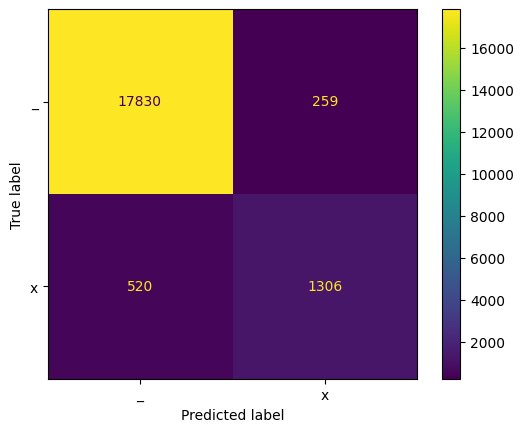

In [51]:
# output the predictions, classification report, confusion matrix
def save_predictions_and_calculate_matrices (feature_file, gold_labels, predictions):
   """A function that evalutes the predictions w.r.t gold labels at the token leel
    : param gold_labels: a nested list of all gold labels/targets
    : param predictions: a nested list of all predictions
    : print: a classification report of individual classes in the pre-defined NER-labels
    : plot: a confusion matrix"""
    
   scope_labels = ['_', 'x']
   #iterating over the nested list to get the raw labels/predictions
   gold_raw=[]
   for label_list_gold in gold_labels:
       for label in label_list_gold:
           gold_raw.append(label)

   predict_raw=[]
   for label_list_crf in predictions:
       for label in label_list_crf:
           predict_raw.append(label)

   #print the classification report and the confusion matrix
   matrices_report = classification_report(  gold_raw, predict_raw, target_names=scope_labels, digits = 3, zero_division= 0)
   print(matrices_report)

   matrix = confusion_matrix( gold_raw, predict_raw, labels= scope_labels )
   
   matrix_display = ConfusionMatrixDisplay(confusion_matrix = matrix, display_labels = scope_labels)
   matrix_display.plot()

   #outputs the gold and predictions to the feature file
   i= 0 #used to trace the position
   with open(feature_file, 'r', encoding='utf-8') as ff1:
        lines = ff1.readlines()
   with open(feature_file, 'w', encoding='utf-8') as ff2:
        for line in lines:
            line= line.strip()
            if not line:
                ff2.write('\n')
            else:
                ff2.write(f"{line}\t{gold_raw[i]}\t{predict_raw[i]}\n")
                i += 1
                

#execuating the function above
save_predictions_and_calculate_matrices("./test_feature_predict.tsv", test_labels, test_predictions)

In general, the model is reliable in classifying tokens into both classes. This is verified by the high macro-averaged (MAv) F1-score (i.e. the unweighted mean of the F1 score for each class) of 0.874. MAv F1 is used here because it treats both classes equally and is therefore more informative than accuracy (0.961) or weighted F1 (0.960) under class imbalance. Noticeably, the model achieved a higher MAv precision than MAv recall by 0.058, suggesting it prioritises correctness over retrieving all relevant tokens (high precision, lower recall).

Model performance per class also shows differences. The precision (0.972) and recall (0.986) for tokens outside the scope (‘_’) are strikingly high, indicating that the model is very competent in addressing this class. This is likely due to the strong dominance of this class in both the training and the test datasets. In comparison, model performance for ‘x’ is weaker but still reasonable. The precision for ‘x’ is 0.835, which is close to the highest scope token precision reported for the shared task (Morante and Blanco, 2012). This is reflected in the significantly lower number of false positives (259) compared to true positives (1306). That said, the model misses some inside-scope tokens (i.e. recall = 0.715). This outcome can be attributed to the false negatives (520) being nearly half the true positives, suggesting that the model is less sensitive to tokens within the negation scope, aligning with the lower priority placed on recall discussed above.


### **5 Standalone Function with examples**

In [39]:
# Standalone function to predict negation scope given a sentence and negation cue.

import pickle

def predict(sentence, neg_cue, model_path='../model/model.pkl'):
    """Standalone predict function for negation scope detection given a sentence and negation cue.

    Assumes only one negation cue in the sentence.

    args:
        sentence: List of strings for a sentence. e.g. ['I', 'do', 'not', 'like', 'apples']
        neg_cue: List of negation cues for the sentence, neg cue where available and '_' for other tokens.
            e.g. ['_', '_', 'not', '_', '_']
        model_path: path to the CRF model
    """
    # Load the model from the model path
    with open(model_path, 'rb') as file:
        model = pickle.load(file)
        
    # Extract the features given the sentence and neg cue
    # We pass the sentence and cue directly instead of a conll file
    features = [extract_features(None, all_sentences=[sentence], all_cues=[neg_cue])]

    # Predict using the model
    prediction = model.predict(features)[0]
    
    return prediction

In [40]:
# Examples

sentence = ['I', 'do', 'not', 'like', 'apples']
cue = ['_', '_', 'not', '_', '_']
print(f'Negation scope for the {sentence}: {predict(sentence, cue)}')

sentence = ['I', 'do', 'not', 'like', 'apples', ',', 'but', 'I', 'love', 'strawberries']
cue = ['_', '_', 'not', '_', '_', '_', '_', '_', '_', '_']
print(f'Negation scope for the {sentence}: {predict(sentence, cue)}')

sentence = ['I', 'am', 'unimpressed', 'by', 'the', 'new', 'album']
cue = ['_', '_', 'un', '_', '_', '_', '_']
print(f'Negation scope for the {sentence}: {predict(sentence, cue)}')

sentence = ['I', 'like', 'oranges', '.']
cue = ['_', '_', '_', '_']
print(f'Negation scope for the {sentence}: {predict(sentence, cue)}')


Negation scope for the ['I', 'do', 'not', 'like', 'apples']: ['x' 'x' '_' 'x' 'x']
Negation scope for the ['I', 'do', 'not', 'like', 'apples', ',', 'but', 'I', 'love', 'strawberries']: ['x' 'x' '_' 'x' 'x' '_' '_' '_' '_' '_']
Negation scope for the ['I', 'am', 'unimpressed', 'by', 'the', 'new', 'album']: ['x' 'x' 'x' 'x' 'x' 'x' 'x']
Negation scope for the ['I', 'like', 'oranges', '.']: ['_' '_' '_' '_']
